# Modele prognozowania

## ARIMA

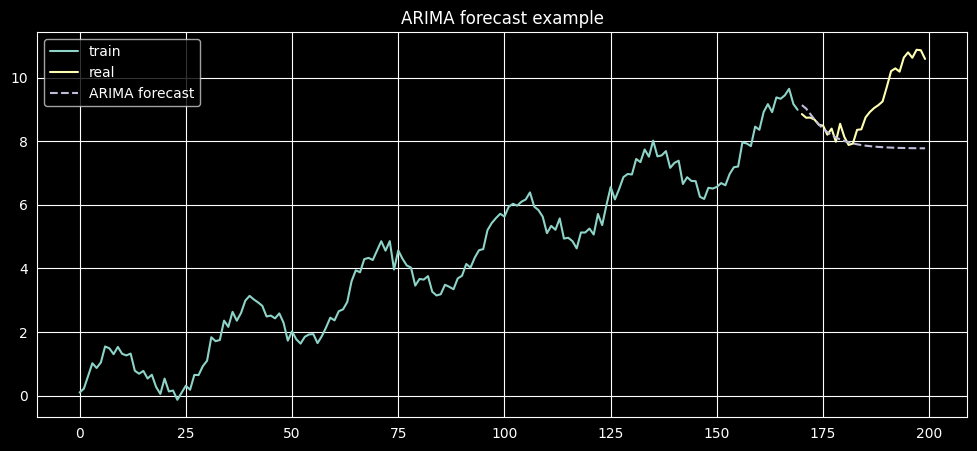

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)

time_steps = 200
t = np.arange(time_steps)
series = 0.05 * t + np.sin(0.2 * t) + 0.2 * np.random.randn(time_steps)

train_size = 170
train, test = series[:train_size], series[train_size:]

# ARIMA order=(p, d, q):
# p=2: AR terms (uses the last 2 lagged values)
# d=1: 1st differencing (models changes to reduce trend / non-stationarity)
# q=2: MA terms (uses the last 2 lagged forecast errors to absorb residual autocorrelation)
model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

print("ARIMA forecast:")
print(forecast)

plt.figure(figsize=(12, 5))
plt.plot(t[:train_size], train, label="train")
plt.plot(t[train_size:], test, label="real")
plt.plot(t[train_size:], forecast, label="ARIMA forecast", linestyle="--")
plt.legend()
plt.title("ARIMA forecast example")
plt.show()

## TimeSeriesTransformer

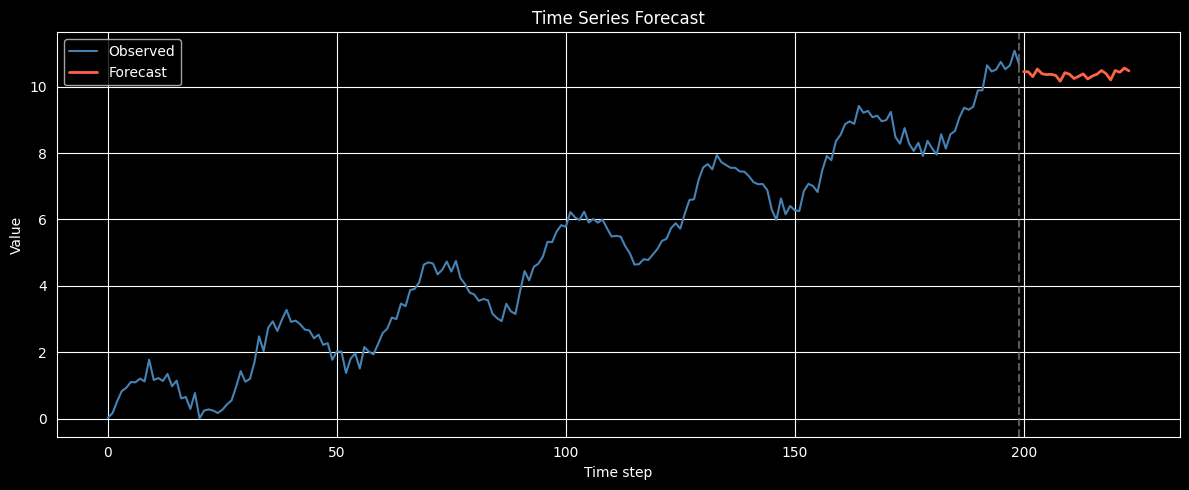

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction

# 1. Generate example data
time_steps = 200
t = np.arange(time_steps)
series = 0.05 * t + np.sin(0.2 * t) + 0.2 * np.random.randn(time_steps)

data = torch.tensor(series, dtype=torch.float32)

# 2. Normalize for training
mean = data.mean()
std = data.std()
data_norm = (data - mean) / std

# 3. Config
context_length = 48
prediction_length = 24
lags = [1, 2, 3, 4, 5, 6, 7]
max_lag = max(lags)
past_length = context_length + max_lag

config = TimeSeriesTransformerConfig(
    prediction_length=prediction_length,
    context_length=context_length,
    lags_sequence=lags,
    num_time_features=1,
    num_dynamic_real_features=0,
    num_static_real_features=0,
    num_static_categorical_features=0,
    scaling="none",  # we already normalized manually
)

model = TimeSeriesTransformerForPrediction(config)

# 4. Build sliding windows
past_windows = []
future_windows = []
past_tf_windows = []
future_tf_windows = []

for start in range(0, len(data_norm) - past_length - prediction_length + 1):
    past = data_norm[start:start + past_length]
    future = data_norm[start + past_length:start + past_length + prediction_length]

    past_windows.append(past)
    future_windows.append(future)

    past_tf_windows.append(torch.arange(start, start + past_length, dtype=torch.float32))
    future_tf_windows.append(torch.arange(start + past_length, start + past_length + prediction_length, dtype=torch.float32))

past_values = torch.stack(past_windows).unsqueeze(-1) if past_windows[0].ndim == 1 else torch.stack(past_windows)
future_values = torch.stack(future_windows).unsqueeze(-1) if future_windows[0].ndim == 1 else torch.stack(future_windows)

past_time_features = torch.stack(past_tf_windows).unsqueeze(-1)
future_time_features = torch.stack(future_tf_windows).unsqueeze(-1)

past_observed_mask = torch.ones_like(past_values)
future_observed_mask = torch.ones_like(future_values)

dataset = TensorDataset(
    past_values, past_time_features, past_observed_mask,
    future_values, future_time_features, future_observed_mask
)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# 5. Train
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

for epoch in range(10):
    total_loss = 0.0
    for batch in loader:
        pv, ptf, pom, fv, ftf, fom = batch

        optimizer.zero_grad()
        outputs = model(
            past_values=pv.squeeze(-1),
            past_time_features=ptf,
            past_observed_mask=pom.squeeze(-1),
            future_values=fv.squeeze(-1),
            future_time_features=ftf,
            future_observed_mask=fom.squeeze(-1),
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}: loss={total_loss / len(loader):.4f}")

# 6. Forecast using the last window
model.eval()
with torch.no_grad():
    last_past_values = data_norm[-past_length:].unsqueeze(0)
    last_past_time_features = torch.arange(len(data_norm) - past_length, len(data_norm), dtype=torch.float32).view(1, past_length, 1)
    last_past_observed_mask = torch.ones_like(last_past_values)

    future_time_features = torch.arange(len(data_norm), len(data_norm) + prediction_length, dtype=torch.float32).view(1, prediction_length, 1)

    forecast = model.generate(
        past_values=last_past_values,
        past_time_features=last_past_time_features,
        past_observed_mask=last_past_observed_mask,
        future_time_features=future_time_features,
    )

    pred_norm = forecast.sequences.mean(dim=1).squeeze(0)
    pred = pred_norm * std + mean

# 7. Plot
history_x = np.arange(len(data))
forecast_x = np.arange(len(data), len(data) + prediction_length)

plt.figure(figsize=(12, 5))
plt.plot(history_x, data.numpy(), label="Observed", color="steelblue")
plt.plot(forecast_x, pred.cpu().numpy(), label="Forecast", color="tomato", linewidth=2)
plt.axvline(len(data) - 1, color="gray", linestyle="--", alpha=0.7)
plt.title("Time Series Forecast")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()